# Final Python Notebook 3: Ensemble and DT
**Author:** Gihan Pasindu

**Reviewer:** Pasan Hirunaka


## PART A: Ensemble Classification
### Leveraged from Tutorial 7: Ensemble Learners (Voting Classifier)
A structural voting classifier combined from foundational Naive Bayes and Logistic Regression algorithms as per module requirements.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# load classification set
df_status = pd.read_csv("loan_approval_status_data.csv")
X_clf = df_status.drop(['loan_approval_status'], axis=1)
y_clf = df_status['loan_approval_status']

# train test split formulation
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.3, stratify=y_clf, random_state=42)

# initialisation of base models
nb = GaussianNB()
lr = LogisticRegression(max_iter=5000)

# base model fitting sequence
nb.fit(X_train_c, y_train_c)
lr.fit(X_train_c, y_train_c)

# assemble and fit unified voting classifier (soft voting for ROC compatibility)
base_learners = [('NB', nb), ('LR', lr)]
ensemble_model = VotingClassifier(base_learners, voting='soft')
ensemble_model.fit(X_train_c, y_train_c)

# generate predictions
y_pred_nb = nb.predict(X_test_c)
y_pred_lr = lr.predict(X_test_c)
y_pred_ens = ensemble_model.predict(X_test_c)

print("Ensemble classification compilation successful.")


C:\Users\Gihan Pasindu\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ensemble classification compilation successful.


C:\Users\Gihan Pasindu\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Leveraged from Tutorial 7: Evaluate the Ensemble Model
Generation of diagnostic classification reports and confusion matrices for the individual base learners and the final ensemble model.



--- Report for Naive Bayes ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     15089
           1       0.68      0.34      0.45      2505

    accuracy                           0.88     17594
   macro avg       0.79      0.65      0.69     17594
weighted avg       0.87      0.88      0.87     17594

Naive Bayes Confusion Matrix Array:
 [[14688   401]
 [ 1664   841]]


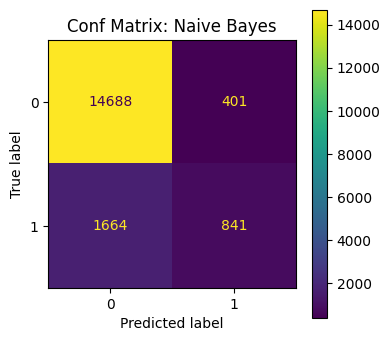

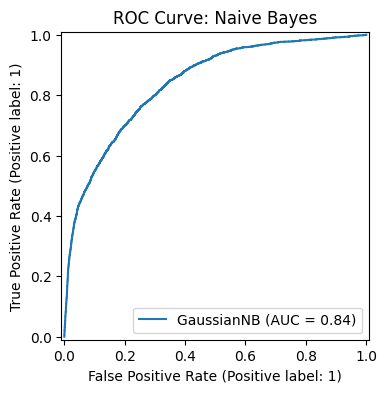


--- Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     15089
           1       0.73      0.36      0.49      2505

    accuracy                           0.89     17594
   macro avg       0.82      0.67      0.71     17594
weighted avg       0.88      0.89      0.87     17594

Logistic Regression Confusion Matrix Array:
 [[14759   330]
 [ 1593   912]]


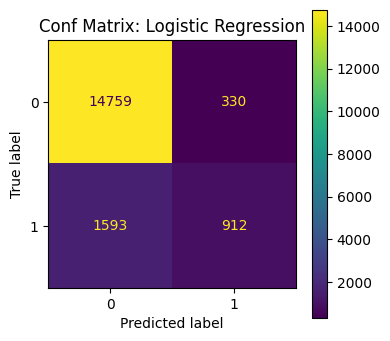

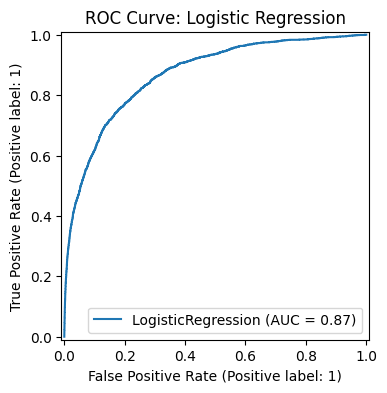


--- Report for Voting Ensemble ---
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     15089
           1       0.72      0.35      0.47      2505

    accuracy                           0.89     17594
   macro avg       0.81      0.66      0.71     17594
weighted avg       0.88      0.89      0.87     17594

Voting Ensemble Confusion Matrix Array:
 [[14754   335]
 [ 1626   879]]


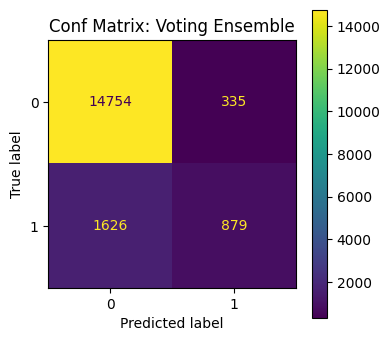

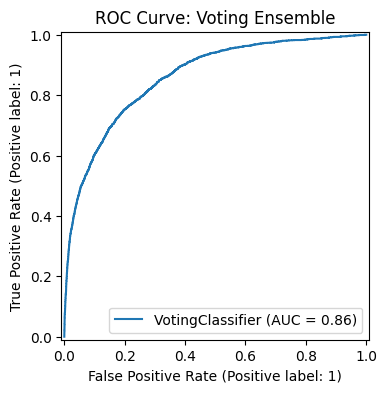

In [2]:
def eval_model(model, name, y_pred):
    print(f"\n--- Report for {name} ---")
    print(classification_report(y_test_c, y_pred))
    
    # conf matrix raw array
    cm = confusion_matrix(y_test_c, y_pred)
    print(f"{name} Confusion Matrix Array:\n", cm)
    
    # conf matrix graph
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_ if hasattr(model, "classes_") else [0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, values_format='.0f')
    plt.title(f"Conf Matrix: {name}")
    plt.show()

    # ROC curve graph
    fig, ax = plt.subplots(figsize=(4, 4))
    RocCurveDisplay.from_estimator(model, X_test_c, y_test_c, ax=ax)
    plt.title(f"ROC Curve: {name}")
    plt.show()

# evaluate all three
eval_model(nb, "Naive Bayes", y_pred_nb)
eval_model(lr, "Logistic Regression", y_pred_lr)
eval_model(ensemble_model, "Voting Ensemble", y_pred_ens)


## PART B: Decision Tree Regression
### Leveraged from Tutorial 6: Regression Decision Trees
Decision tree mechanisms established for resolving max loan amount outputs given numerical dataset constraints.


In [3]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import sklearn.metrics as metrics

# load regression dataset sequence
df_reg = pd.read_csv("loan_max_amount_data.csv")

# --- Case Study B Task 1 evidence ---
print("Dimensions of regression subset:", df_reg.shape)
print("Feature names:", list(df_reg.columns))
# ------------------------------------

X_reg = df_reg.drop(['max_allowed_loan'], axis=1)
y_reg = df_reg['max_allowed_loan']

# split standard 90/10 proportional allocation
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.1, random_state=10)

# 1. unrestrained tree architecture DT-1
dt1 = DecisionTreeRegressor(random_state=42)
dt1.fit(X_train_r, y_train_r)
y_pred_dt1 = dt1.predict(X_test_r)
print("Depth configuration for DT-1:", dt1.tree_.max_depth)

# 2. limited depth architecture DT-2
dt2 = DecisionTreeRegressor(max_depth=4, random_state=42)
dt2.fit(X_train_r, y_train_r)
y_pred_dt2 = dt2.predict(X_test_r)
print("Depth configuration for DT-2 locked continuously to 4.")


Dimensions of regression subset: (50295, 11)
Feature names: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'max_allowed_loan']
Depth configuration for DT-1: 24
Depth configuration for DT-2 locked continuously to 4.


### Leveraged from Tutorial 6: Visualising Decision Trees
Graphically mapping both the fully grown tree (DT-1) and the pruned model (DT-2). Note: DT-1 is clipped to 6 levels for legibility.


Visualising Top 6 levels of Fully Grown Tree (DT-1)...


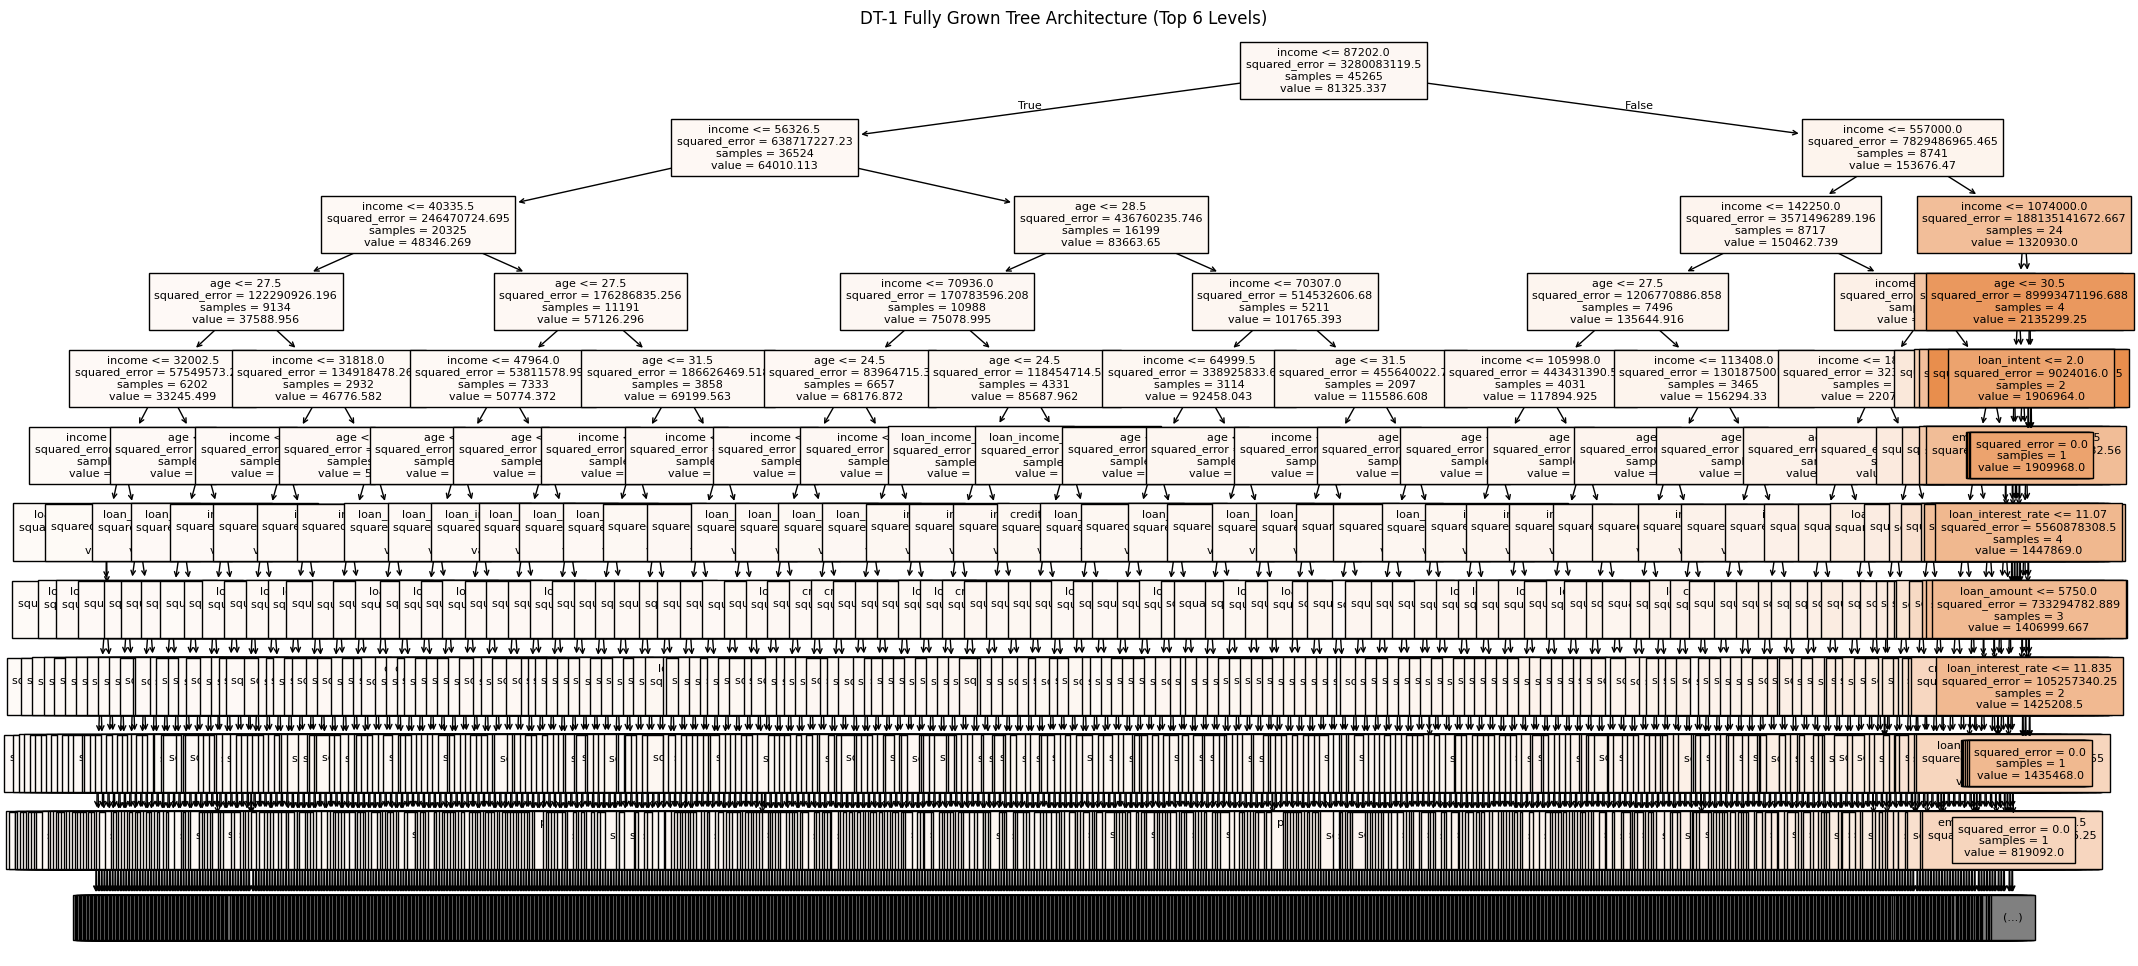

Visualising Pruned Tree (DT-2)


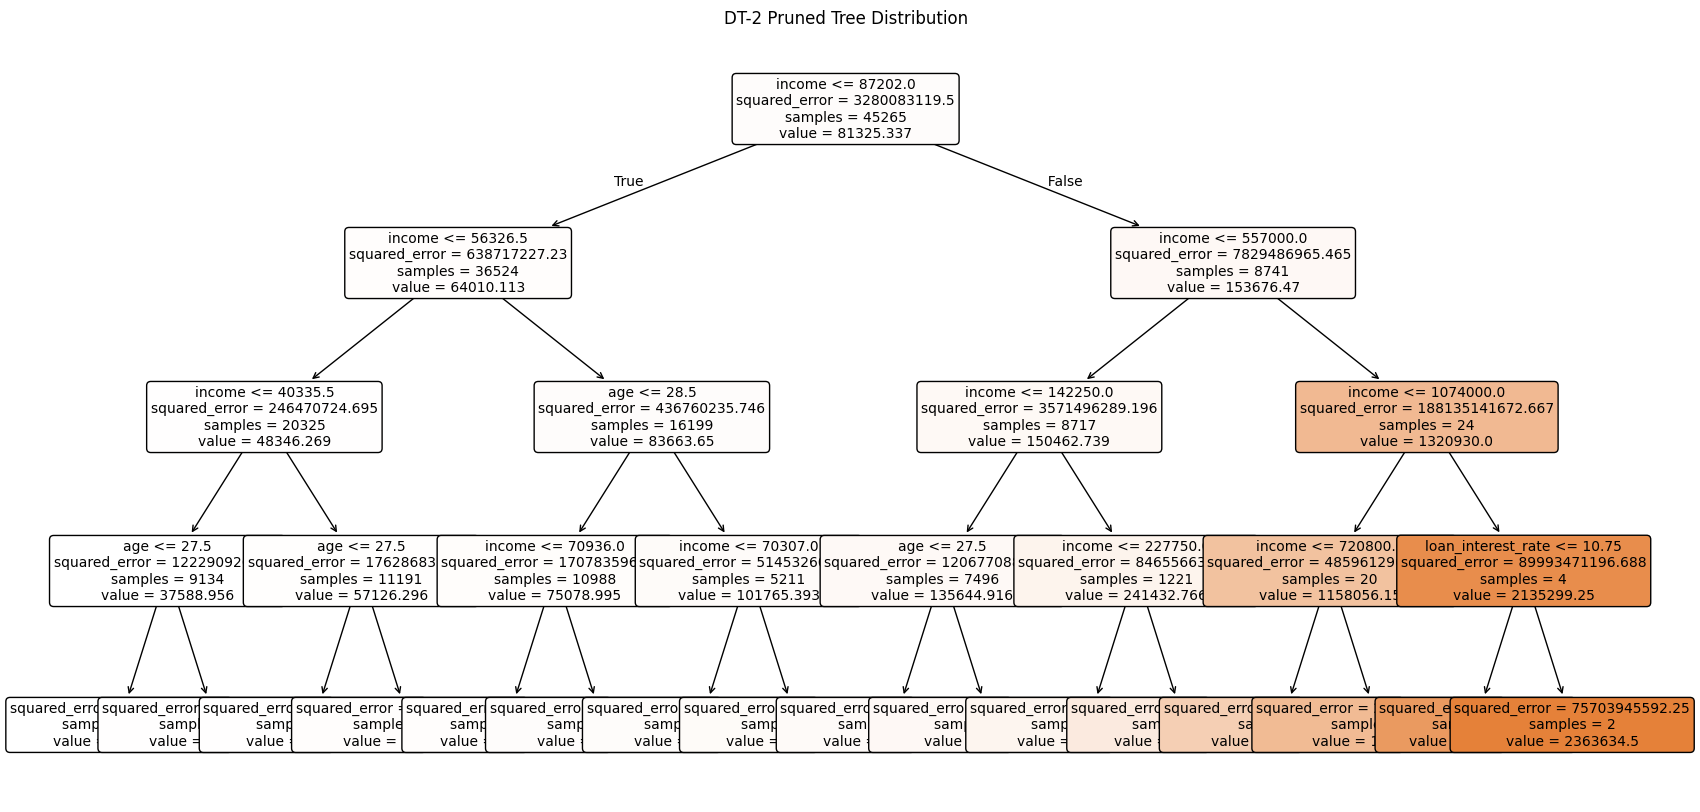

In [5]:
# plot DT-1 (Visualising only top levels for clarity)
print("Visualising Top 6 levels of Fully Grown Tree (DT-1)...")
plt.figure(figsize=(25, 12))
plot_tree(dt1, feature_names=list(X_train_r.columns), filled=True, max_depth=10, fontsize=8)
plt.title("DT-1 Fully Grown Tree Architecture (Top 6 Levels)")
plt.show()

# plot DT-2 (Pruned)
print("Visualising Pruned Tree (DT-2)")
plt.figure(figsize=(20, 10))
plot_tree(dt2, feature_names=list(X_train_r.columns), filled=True, rounded=True, fontsize=10)
plt.title("DT-2 Pruned Tree Distribution")
plt.show()


### Leveraged from Tutorial 6: Evaluating Regression Models
Systematic retrieval of standard error metrics (MAE, MSE, RMSE, R2) to document DT regression stability.


In [6]:
def retrieve_metrics(name, y_test, y_pred):
    print(f"\n--- Output Metrics for {name} ---")
    print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
    print('MSE:', metrics.mean_squared_error(y_test, y_pred))
    print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
    print('R-Square:', metrics.r2_score(y_test, y_pred))

retrieve_metrics("DT-1 Unlimited", y_test_r, y_pred_dt1)
retrieve_metrics("DT-2 Limited Depth", y_test_r, y_pred_dt2)



--- Output Metrics for DT-1 Unlimited ---
MAE: 1914.1485089463222
MSE: 1413853839.907157
RMSE: 37601.24785039929
R-Square: 0.7439341253787111

--- Output Metrics for DT-2 Limited Depth ---
MAE: 12520.131611019138
MSE: 1745120988.858212
RMSE: 41774.64528704238
R-Square: 0.6839376746599981


### Predicting Maximum Loan Amount for Client Case Study
Applying predictive variables into DT-2 regressor mapping sequence for specific case study identification (Client 60256).


In [7]:
# mapping protocol for Client 60256
cols = X_reg.columns.tolist()
client_test = pd.DataFrame([[56.0, 57000, 3, 15, 2, 25700, 23.0, 0.10, 0, 35]], columns=cols)

# execution of dt2 prediction matrix
prediction = dt2.predict(client_test)[0]
print(f"Maximum potential loan allocation for Client 60256 resolving strictly to: £{prediction:,.2f}")


Maximum potential loan allocation for Client 60256 resolving strictly to: £92,458.04
